In [46]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# GPS 데이터를 저장할 리스트
gps_data_m = []
imu_data = []
Time = ''
# CSV 파일 읽기
with open(r"D:\cansat_log\Cansat_Log_20240807_131207\cansat_log_20240807_131207.csv", 'r') as f:
    rdr = csv.reader(f)
    
    x = -1
    y = -1
    
    for line in rdr:
        if line[0][:4] == '2024':
            Time = f'{line[0][9:11]}:{line[0][11:13]}:{line[0][13:15]}.{line[0][15:19]}'
        elif line[0] == 'GPS_DATA' and line[3] != '':
            if x == -1 and y == -1:
                x = float(line[3])
                y = float(line[5])
            
            Lat = (float(line[3]) - x) / 100 * 111.19 * 1000
            Lon = (float(line[5]) - y) / 100 * 111.19 * 1000
            Alt = float(line[10])
            
            gps_data_m.append([Time, Lat, Lon, Alt])
        
        elif line[0] == 'IMU_DATA' and x!=-1 and y!=-1:
            R = float(line[1][1:])
            P = float(line[2])
            Y = float(line[3])
            aX = float(line[4])
            aY = float(line[5])
            aZ = float(line[6])
            
            imu_data.append([Time,R,P,Y,aX,aY,aZ])

TypeError: '_csv.reader' object is not subscriptable

In [44]:
print(gps_data_m)

[['13:16:38.1602', 0.0, 0.0, 50.1], ['13:16:39.1614', -1.1230189999456344, -0.2223800004498116, 52.6], ['13:16:40.1658', -1.5677789998339902, -0.2223800004498116, 54.7], ['13:16:41.1682', -2.3572279996105405, 0.0, 57.0], ['13:16:42.1698', -2.53513199966701, -0.36692700084331586, 57.0], ['13:16:43.1743', -1.601136000002589, -0.6893780007876557, 53.9], ['13:16:44.1765', -0.8450439998890033, -1.2119710017435863, 52.0], ['13:16:45.1796', -0.6226639999448252, -1.5344220016879262, 50.7], ['13:16:46.1825', -0.4225219999445016, -1.7012070015196514, 50.2], ['13:16:47.1845', -0.2668559998318869, -1.9569440011267945, 50.3], ['13:16:48.1893', 0.04447600039334248, -2.0792530000595435, 48.9], ['13:16:49.1899', 0.4225220004501352, -2.257157001632913, 47.5], ['13:16:50.1939', 0.7672110003383296, -2.4906560018018356, 46.5], ['13:16:51.1963', 1.245328000395284, -2.4239420014646385, 45.8], ['13:16:52.1994', 1.3898750002831548, -2.79086900028542, 45.6], ['13:16:53.2106', 1.6122550002273328, -3.02436800045

In [37]:
with open('D:\cansat_log\Cansat_Log_20240807_131207\gps_data_m.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Time', 'Latitude', 'Longitude', 'Altitude'])
    writer.writerows(gps_data_m)

In [41]:
with open('D:\cansat_log\Cansat_Log_20240807_131207\imu_data.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Time', 'Roll', 'Pitch', 'Yaw', 'aX', 'aY', 'aZ'])
    writer.writerows(imu_data)

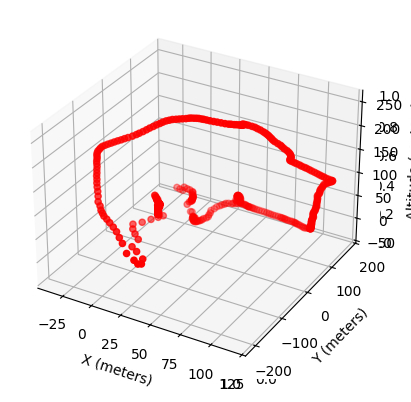

In [18]:


# 3차원 그래프 플로팅
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 데이터 추출
timestamps = [data[0] for data in gps_data_m]
x_coords = [data[1] for data in gps_data_m]
y_coords = [data[2] for data in gps_data_m]
z_coords = [data[3] for data in gps_data_m]  # Altitude (고도)

# 그래프에 점 찍기
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_coords, y_coords, z_coords, c='r', marker='o')

# 축 레이블 설정
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.set_zlabel('Altitude (meters)')

# 그래프 보이기
plt.show()


In [21]:
print(imu_data)

[[-103.23, -79.55, -74.45, 0.0, 0.0, 0.0], [-103.24, -79.56, -74.43, 0.0, 0.0, 0.0], [-103.23, -79.56, -74.45, 0.0, 0.0, 0.0], [-103.24, -79.56, -74.44, 0.0, 0.0, 0.0], [-103.25, -79.56, -74.43, 0.0, 0.0, 0.0], [-103.24, -79.55, -74.43, 0.0, 0.0, 0.0], [-103.25, -79.55, -74.43, 0.0, 0.0, 0.0], [-103.23, -79.55, -74.45, 0.0, 0.0, 0.0], [-103.22, -79.56, -74.46, 0.0, 0.0, 0.0], [-103.23, -79.56, -74.45, 0.0, 0.0, 0.0], [-103.23, -79.56, -74.44, 0.0, 0.0, 0.0], [-103.22, -79.56, -74.46, 0.0, 0.0, 0.0], [-103.22, -79.55, -74.46, 0.0, 0.0, 0.0], [-103.21, -79.55, -74.47, 0.0, 0.0, 0.0], [-103.14, -79.55, -74.53, 0.65, 1.38, 3.45], [-103.11, -79.55, -74.57, 0.23, 0.59, -5.64], [-103.19, -79.54, -74.5, 0.65, 0.77, 1.68], [-103.09, -79.53, -74.59, 1.63, 0.71, 2.54], [-103.09, -79.51, -74.59, 0.77, 0.16, -0.09], [-103.13, -79.49, -74.55, 1.26, 0.35, 0.95], [-103.16, -79.5, -74.52, 1.87, 0.83, 0.46], [-103.11, -79.49, -74.56, -0.38, -1.24, -0.82], [-102.97, -79.48, -74.68, -0.75, -0.63, -2.65], 

In [30]:
import pandas as pd

# Load the data
gps_data = pd.read_csv('C:\\Users\\user\\Desktop\\cansat\\gps_data_m.csv')
imu_data = pd.read_csv('C:\\Users\\user\\Desktop\\cansat\\imu_data.csv')

gps_data_head = gps_data.head()
imu_data_head = imu_data.head()

gps_data_head, imu_data_head


(            Time  Latitude  Longitude  Altitude
 0  13:16:38.1602  0.000000   0.000000      50.1
 1  13:16:39.1614 -1.123019  -0.222380      52.6
 2  13:16:40.1658 -1.567779  -0.222380      54.7
 3  13:16:41.1682 -2.357228   0.000000      57.0
 4  13:16:42.1698 -2.535132  -0.366927      57.0,
             Time    Roll  Pitch    Yaw   aX   aY   aZ
 0  13:16:38.1602 -103.23 -79.55 -74.45  0.0  0.0  0.0
 1  13:16:38.2259 -103.24 -79.56 -74.43  0.0  0.0  0.0
 2  13:16:38.2922 -103.23 -79.56 -74.45  0.0  0.0  0.0
 3  13:16:38.3601 -103.24 -79.56 -74.44  0.0  0.0  0.0
 4  13:16:38.4265 -103.25 -79.56 -74.43  0.0  0.0  0.0)

In [31]:
import numpy as np

# Convert time to a consistent format (seconds from start)
def convert_time(time_str):
    h, m, s = map(float, time_str.split(':'))
    return h * 3600 + m * 60 + s

gps_data['Time_sec'] = gps_data['Time'].apply(convert_time)
imu_data['Time_sec'] = imu_data['Time'].apply(convert_time)

# Interpolate IMU data to match GPS timestamps
imu_interpolated = pd.DataFrame()
imu_interpolated['Time_sec'] = gps_data['Time_sec']

for column in imu_data.columns[1:]:
    imu_interpolated[column] = np.interp(gps_data['Time_sec'], imu_data['Time_sec'], imu_data[column])

# Combine the data into a single DataFrame
combined_data = pd.concat([gps_data[['Time_sec', 'Latitude', 'Longitude', 'Altitude']], imu_interpolated.drop(columns=['Time_sec'])], axis=1)

combined_data.head()


,Time_sec,Latitude,Longitude,Altitude,Roll,Pitch,Yaw,aX,aY,aZ
0,47798.1602,0.000000,0.000000,50.1,-103.230000,-79.550000,-74.450000,0.000000,0.000000,0.000000
1,47799.1614,-1.123019,-0.222380,52.6,-103.213792,-79.550000,-74.466208,0.000000,0.000000,0.000000
2,47800.1658,-1.567779,-0.222380,54.7,-102.674131,-79.400000,-75.017607,1.069572,0.767633,1.935921
3,47801.1682,-2.357228,0.000000,57.0,-95.107445,-79.176279,-82.515424,-0.383564,-2.026203,-0.733484
4,47802.1698,-2.535132,-0.366927,57.0,-73.397974,-81.363561,-101.006581,1.183444,-2.623704,-0.788453


In [32]:
import numpy as np

# Convert time to a consistent format (seconds from start)
def convert_time(time_str):
    h, m, s = map(float, time_str.split(':'))
    return h * 3600 + m * 60 + s

gps_data['Time_sec'] = gps_data['Time'].apply(convert_time)
imu_data['Time_sec'] = imu_data['Time'].apply(convert_time)

# Interpolate IMU data to match GPS timestamps
imu_interpolated = pd.DataFrame()
imu_interpolated['Time_sec'] = gps_data['Time_sec']

for column in imu_data.columns[1:]:
    imu_interpolated[column] = np.interp(gps_data['Time_sec'], imu_data['Time_sec'], imu_data[column])

# Combine the data into a single DataFrame
combined_data = pd.concat([gps_data[['Time_sec', 'Latitude', 'Longitude', 'Altitude']], imu_interpolated.drop(columns=['Time_sec'])], axis=1)

combined_data.head()


,Time_sec,Latitude,Longitude,Altitude,Roll,Pitch,Yaw,aX,aY,aZ
0,47798.1602,0.000000,0.000000,50.1,-103.230000,-79.550000,-74.450000,0.000000,0.000000,0.000000
1,47799.1614,-1.123019,-0.222380,52.6,-103.213792,-79.550000,-74.466208,0.000000,0.000000,0.000000
2,47800.1658,-1.567779,-0.222380,54.7,-102.674131,-79.400000,-75.017607,1.069572,0.767633,1.935921
3,47801.1682,-2.357228,0.000000,57.0,-95.107445,-79.176279,-82.515424,-0.383564,-2.026203,-0.733484
4,47802.1698,-2.535132,-0.366927,57.0,-73.397974,-81.363561,-101.006581,1.183444,-2.623704,-0.788453


In [34]:
# Import required libraries for the EKF
from scipy.linalg import block_diag

# Define the initial state vector (position, velocity, orientation)
state = np.zeros(9)  # [x, y, z, v_x, v_y, v_z, roll, pitch, yaw]

# Define initial covariance matrix (uncertainty in the initial state)
P = np.eye(9) * 1.0

# Define the process noise covariance matrix (Q)
# This matrix represents the uncertainty in the process model
Q = block_diag(np.eye(3) * 0.1, np.eye(3) * 0.1, np.eye(3) * 0.1)

# Define the measurement noise covariance matrix (R)
# This matrix represents the uncertainty in the GPS measurements
R = np.eye(3) * 5.0  # Higher values indicate less trust in the GPS measurements

# State transition function: predict the next state based on the current state and IMU data
def predict_state(state, dt, imu):
    x, y, z, v_x, v_y, v_z, roll, pitch, yaw = state
    
    # Update position based on velocity
    x += v_x * dt
    y += v_y * dt
    z += v_z * dt
    
    # Update velocity based on acceleration (considering the orientation)
    R = np.array([[np.cos(pitch) * np.cos(yaw), 
                   np.cos(pitch) * np.sin(yaw), 
                   -np.sin(pitch)],
                  [np.sin(roll) * np.sin(pitch) * np.cos(yaw) - np.cos(roll) * np.sin(yaw),
                   np.sin(roll) * np.sin(pitch) * np.sin(yaw) + np.cos(roll) * np.cos(yaw),
                   np.sin(roll) * np.cos(pitch)],
                  [np.cos(roll) * np.sin(pitch) * np.cos(yaw) + np.sin(roll) * np.sin(yaw),
                   np.cos(roll) * np.sin(pitch) * np.sin(yaw) - np.sin(roll) * np.cos(yaw),
                   np.cos(roll) * np.cos(pitch)]])
    
    a = np.array([imu['aX'], imu['aY'], imu['aZ']])
    acc = R @ a
    
    v_x += acc[0] * dt
    v_y += acc[1] * dt
    v_z += acc[2] * dt
    
    # Update orientation
    roll += imu['Roll'] * dt
    pitch += imu['Pitch'] * dt
    yaw += imu['Yaw'] * dt
    
    return np.array([x, y, z, v_x, v_y, v_z, roll, pitch, yaw])

# EKF prediction step
def ekf_predict(state, P, imu, dt):
    state = predict_state(state, dt, imu)
    F = np.eye(9)  # State transition matrix, assuming linear motion
    
    # Update the covariance matrix
    P = F @ P @ F.T + Q
    
    return state, P

# EKF update step
def ekf_update(state, P, gps):
    H = np.zeros((3, 9))
    H[0, 0] = 1  # x position
    H[1, 1] = 1  # y position
    H[2, 2] = 1  # z position
    
    # Calculate the innovation (residual) between the measurement and the prediction
    z = np.array([gps['Latitude'], gps['Longitude'], gps['Altitude']])
    y = z - H @ state
    
    # Innovation covariance
    S = H @ P @ H.T + R
    
    # Kalman gain
    K = P @ H.T @ np.linalg.inv(S)
    
    # Update the state estimate
    state = state + K @ y
    
    # Update the covariance matrix
    P = (np.eye(len(P)) - K @ H) @ P
    
    return state, P

# Run the EKF over all the data
states = []
dt = 1.0  # Assuming a 1-second interval between measurements

for i in range(len(combined_data)):
    imu = combined_data.iloc[i]
    gps = combined_data.iloc[i]
    
    # Prediction step
    state, P = ekf_predict(state, P, imu, dt)
    
    # Update step
    state, P = ekf_update(state, P, gps)
    
    states.append(state)

# Convert the list of states to a DataFrame for easier analysis
ekf_results = pd.DataFrame(states, columns=['x', 'y', 'z', 'v_x', 'v_y', 'v_z', 'roll', 'pitch', 'yaw'])
ekf_results.head()


,x,y,z,v_x,v_y,v_z,roll,pitch,yaw
0,0.000000,0.000000,9.034426,0.000000,0.000000,0.000000,-103.230000,-79.550000,-74.450000
1,-0.187425,-0.037114,16.305272,0.000000,0.000000,0.000000,-206.443792,-159.100000,-148.916208
2,-0.404783,-0.066287,22.351097,1.567352,-1.723351,0.233466,-309.117923,-238.500000,-223.933815
3,0.632073,-1.519907,27.771583,0.482869,-0.218432,1.395247,-404.225368,-317.676279,-306.449238
4,0.582676,-1.538356,33.225553,3.029739,0.699660,0.139628,-477.623342,-399.039840,-407.455819


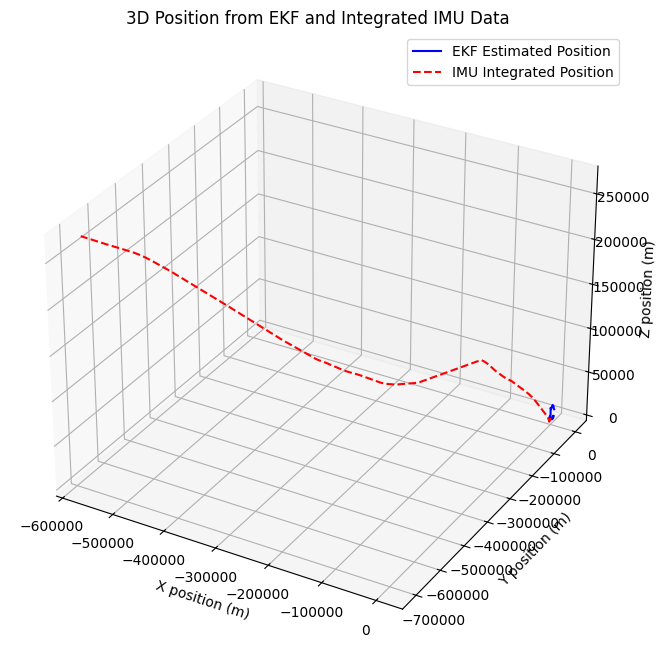

In [35]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract position data from EKF results
x_ekf = ekf_results['x'].values
y_ekf = ekf_results['y'].values
z_ekf = ekf_results['z'].values

# Integrate IMU accelerations to obtain position
dt = 1.0  # Assuming 1-second intervals
imu_position = np.zeros((len(combined_data), 3))
velocity = np.zeros(3)

for i in range(1, len(combined_data)):
    imu = combined_data.iloc[i]
    prev_imu = combined_data.iloc[i-1]
    
    # Integrate acceleration to update velocity
    velocity += 0.5 * dt * (imu[['aX', 'aY', 'aZ']].values + prev_imu[['aX', 'aY', 'aZ']].values)
    
    # Integrate velocity to update position
    imu_position[i] = imu_position[i-1] + velocity * dt

# Plot the results
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot EKF results
ax.plot(x_ekf, y_ekf, z_ekf, label='EKF Estimated Position', color='blue')

# Plot IMU integrated results
ax.plot(imu_position[:, 0], imu_position[:, 1], imu_position[:, 2], label='IMU Integrated Position', color='red', linestyle='dashed')

# Labels and legend
ax.set_xlabel('X position (m)')
ax.set_ylabel('Y position (m)')
ax.set_zlabel('Z position (m)')
ax.set_title('3D Position from EKF and Integrated IMU Data')
ax.legend()

plt.show()


In [2]:
m,n,h = map(int,input().split())
d=[[[0]*(z) for _ in range(m)] for _ in range(n)]
di=[1,-1,0,0,0,0]
dj=[0,0,1,-1,0,0]
dk=[0,0,0,0,1,-1]
p=[]
f=0
for k in range(h):
    for i in range(n):
        a = map(int,input().split())
        for j in range(m):
            d[i][j]=a[j]
            if a[j]=='1':
                p.append((i,j,k))

while f!=len(p):
    x,y,z = p[f]
    for i in range(6):
        nx=x+di[i]
        ny=y+dj[i]
        nz=z+dk[i]
        if nx>=0 and nx<n and ny>=0 and ny<m and nz>=0 and nz<h:
            if d[dx][dy]==0:
                p.append([dx,dy])
                d[dx][dy]=d[x][y]+1
    f+=1

def ans():
    ma=0
    for i in range(m):
        for j in range(n):
            if d[i][j]==0:
                print(-1)
                return
            if d[i][j]>ma:
                ma=d[i][j]
    print(ma-1)

ans()


4 20


In [5]:
n,m,h = map(int,input().split())
d=[[[0]*(n) for _ in range(m)] for _ in range(h)]
print(d)

[[[0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]], [[0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]]
